# AgriMind Phase 3: Agricultural Crop Price Forecasting using RNN, LSTM, and GRU

This notebook is prepared according to the **AgriMind proposal** and the **AI project submission guideline**.

## Important honesty note

The selected dataset is an **Indian crop market price dataset**, not a direct pesticide/fertilizer price dataset. Therefore, this Phase 3 implementation should be described as:

> Agricultural crop market price forecasting using RNN, LSTM, and GRU.

This still supports the AgriMind supply-chain and market forecasting component. If a pesticide/fertilizer price dataset is later added, the same pipeline can be reused.

## Dataset path used

```text
E:\AI Project\AgriMind_Project\datasets\Fertilizer_Price_Dataset\crop_price_dataset.csv
```

## Guideline requirements covered

1. Source of dataset  
2. Dataset characteristics  
3. Data preprocessing  
   - importing libraries  
   - importing dataset  
   - train/validation/test split  
   - handling missing values  
   - treating outliers  
   - removing duplicate records  
   - feature scaling  
   - handling categorical variables  
4. Feature selection approach  
5. RNN, LSTM, and GRU model development  
6. Underfitting/overfitting control  
   - dropout  
   - early stopping  
   - validation loss monitoring  
   - learning-rate reduction  
7. Evaluation metrics  
   - MAE  
   - MSE  
   - RMSE  
   - MAPE  
   - R² Score  
8. Experimental results  
   - training/testing results  
   - performance metrics  
   - graphs  
   - actual vs predicted visualizations  
   - model comparison  
   - trend-direction confusion matrix  
9. Saving models, scalers, results, screenshots, and experiment report

In [2]:
# ============================================================
# Block 1: Import libraries and set environment
# ============================================================

import os
import sys
import json
import math
import pickle
import subprocess
import warnings

warnings.filterwarnings("ignore")

# Reduce possible TensorFlow CPU/thread issues on Windows
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("TF_NUM_INTRAOP_THREADS", "1")
os.environ.setdefault("TF_NUM_INTEROP_THREADS", "1")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow"
}

for import_name, package_name in required_packages.items():
    try:
        __import__(import_name)
    except ModuleNotFoundError:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU available: []


In [4]:
# ============================================================
# Block 2: Define exact project paths for Phase 3
# ============================================================

import os

# Main project folder
PROJECT_DIR = r"E:\AI Project\AgriMind_Project"

# Phase 3 dataset path
# According to your current folder structure:
# datasets > Fertilizer_Prize_Dataset > crop_price_dataset.csv
DATASET_PATH = r"E:\AI Project\AgriMind_Project\datasets\Fertilizer_Prize_Dataset\crop_price_dataset.csv"

# Phase 3 output folders
MODEL_DIR = r"E:\AI Project\AgriMind_Project\models\phase3_crop_price_forecasting"
RESULTS_DIR = r"E:\AI Project\AgriMind_Project\results\phase3_crop_price_forecasting"
SCREENSHOTS_DIR = r"E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting"

# Create output folders automatically if they do not exist
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(SCREENSHOTS_DIR, exist_ok=True)

# Check whether all important paths exist
print("Project directory exists:", os.path.exists(PROJECT_DIR))
print("Dataset file exists:", os.path.exists(DATASET_PATH))
print("Dataset path:", DATASET_PATH)
print("Model folder:", MODEL_DIR)
print("Results folder:", RESULTS_DIR)
print("Screenshots folder:", SCREENSHOTS_DIR)

# Stop execution if dataset file is missing
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found: {DATASET_PATH}")

Project directory exists: True
Dataset file exists: True
Dataset path: E:\AI Project\AgriMind_Project\datasets\Fertilizer_Prize_Dataset\crop_price_dataset.csv
Model folder: E:\AI Project\AgriMind_Project\models\phase3_crop_price_forecasting
Results folder: E:\AI Project\AgriMind_Project\results\phase3_crop_price_forecasting
Screenshots folder: E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting


In [5]:
# ============================================================
# Block 3: Import dataset
# ============================================================

df_original = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df_original.shape)

display(df_original.head())
display(df_original.tail())

Dataset loaded successfully.
Dataset shape: (2810, 9)


,month,commodity_name,avg_modal_price,avg_min_price,avg_max_price,state_name,district_name,calculationType,change
0,2025-03-01,Maize,2341.58,2191.23,2402.98,India,All,Monthly,-14.43
1,2025-02-01,Maize,2356.01,2202.35,2414.46,India,All,Monthly,-26.19
2,2025-01-01,Maize,2382.20,2221.31,2448.22,India,All,Monthly,53.42
3,2024-12-01,Maize,2328.78,2164.86,2411.66,India,All,Monthly,55.32
4,2024-11-01,Maize,2273.46,2077.63,2377.78,India,All,Monthly,35.48


,month,commodity_name,avg_modal_price,avg_min_price,avg_max_price,state_name,district_name,calculationType,change
2805,2010-05-01,Coconut,3093.35,2564.30,3600.61,India,All,Monthly,-33.62
2806,2010-04-01,Coconut,3126.97,2666.44,3594.63,India,All,Monthly,138.53
2807,2010-03-01,Coconut,2988.44,2561.90,3406.92,India,All,Monthly,-12757.26
2808,2010-02-01,Coconut,15745.70,11634.74,19899.66,India,All,Monthly,12576.70
2809,2010-01-01,Coconut,3169.00,2773.97,3562.30,India,All,Monthly,NaN


In [6]:
# ============================================================
# Block 4: Source of dataset and dataset characteristics
# ============================================================

DATASET_SOURCE = "Kaggle Crop Price Prediction Dataset in India, saved locally as crop_price_dataset.csv. Original dataset link should be cited in the report/presentation."

dataset_characteristics = {
    "dataset_path": DATASET_PATH,
    "dataset_source": DATASET_SOURCE,
    "number_of_rows": int(df_original.shape[0]),
    "number_of_columns": int(df_original.shape[1]),
    "column_names": list(df_original.columns),
    "total_missing_values": int(df_original.isnull().sum().sum()),
    "duplicate_rows": int(df_original.duplicated().sum())
}

print(json.dumps(dataset_characteristics, indent=4))

{
    "dataset_path": "E:\\AI Project\\AgriMind_Project\\datasets\\Fertilizer_Prize_Dataset\\crop_price_dataset.csv",
    "dataset_source": "Kaggle Crop Price Prediction Dataset in India, saved locally as crop_price_dataset.csv. Original dataset link should be cited in the report/presentation.",
    "number_of_rows": 2810,
    "number_of_columns": 9,
    "column_names": [
        "month",
        "commodity_name",
        "avg_modal_price",
        "avg_min_price",
        "avg_max_price",
        "state_name",
        "district_name",
        "calculationType",
        "change"
    ],
    "total_missing_values": 16,
    "duplicate_rows": 0
}


In [7]:
# ============================================================
# Block 5: Dataset information and statistical summary
# ============================================================

print("Dataset information")
print("-------------------")
df_original.info()

print()
print("Numerical column summary")
display(df_original.describe(include=[np.number]))

print()
print("Categorical column summary")
display(df_original.describe(include=["object"]))

Dataset information
-------------------
<class 'pandas.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   month            2810 non-null   str    
 1   commodity_name   2810 non-null   str    
 2   avg_modal_price  2810 non-null   float64
 3   avg_min_price    2810 non-null   float64
 4   avg_max_price    2810 non-null   float64
 5   state_name       2810 non-null   str    
 6   district_name    2810 non-null   str    
 7   calculationType  2810 non-null   str    
 8   change           2794 non-null   float64
dtypes: float64(4), str(5)
memory usage: 197.7 KB

Numerical column summary


,avg_modal_price,avg_min_price,avg_max_price,change
count,2810.000000,2810.000000,2810.000000,2794.000000
mean,4878.738327,4654.972292,5226.054630,21.227505
std,5217.404278,8586.774537,5931.616637,1606.987231
min,7.000000,5.000000,10.000000,-29221.430000
25%,1871.800000,1748.487500,1963.757500,-74.612500
50%,3347.715000,3106.315000,3539.950000,9.465000
75%,5530.377500,4992.290000,6005.230000,102.910000
max,45412.600000,377904.120000,76757.630000,31566.670000



Categorical column summary


,month,commodity_name,state_name,district_name,calculationType
count,2810,2810,2810,2810,2810
unique,183,16,1,1,1
top,2022-10-01,Maize,India,All,Monthly
freq,16,183,2810,2810,2810


In [8]:
# ============================================================
# Block 6: Clean column names and remove duplicate records
# ============================================================

df = df_original.copy()

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("/", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace(".", "_", regex=False)
)

print("Cleaned column names:")
print(list(df.columns))

rows_before = df.shape[0]
df = df.drop_duplicates()
rows_after = df.shape[0]

print()
print("Rows before duplicate removal:", rows_before)
print("Rows after duplicate removal:", rows_after)
print("Duplicate records removed:", rows_before - rows_after)

Cleaned column names:
['month', 'commodity_name', 'avg_modal_price', 'avg_min_price', 'avg_max_price', 'state_name', 'district_name', 'calculationtype', 'change']

Rows before duplicate removal: 2810
Rows after duplicate removal: 2810
Duplicate records removed: 0


In [9]:
# ============================================================
# Block 7: Detect and validate important columns
# ============================================================

# Expected columns from the uploaded dataset:
# month, commodity_name, avg_modal_price, avg_min_price, avg_max_price,
# state_name, district_name, calculationType, change

def find_column(possible_names, columns):
    columns_lower = {col.lower(): col for col in columns}
    for name in possible_names:
        if name.lower() in columns_lower:
            return columns_lower[name.lower()]
    return None

DATE_COLUMN = find_column(["month", "date", "year_month", "period"], df.columns)
TARGET_COLUMN = find_column(["avg_modal_price", "modal_price", "average_price", "price"], df.columns)
MIN_PRICE_COLUMN = find_column(["avg_min_price", "min_price"], df.columns)
MAX_PRICE_COLUMN = find_column(["avg_max_price", "max_price"], df.columns)
COMMODITY_COLUMN = find_column(["commodity_name", "commodity", "crop", "crop_name"], df.columns)
STATE_COLUMN = find_column(["state_name", "state"], df.columns)
DISTRICT_COLUMN = find_column(["district_name", "district"], df.columns)

print("Detected DATE_COLUMN:", DATE_COLUMN)
print("Detected TARGET_COLUMN:", TARGET_COLUMN)
print("Detected MIN_PRICE_COLUMN:", MIN_PRICE_COLUMN)
print("Detected MAX_PRICE_COLUMN:", MAX_PRICE_COLUMN)
print("Detected COMMODITY_COLUMN:", COMMODITY_COLUMN)
print("Detected STATE_COLUMN:", STATE_COLUMN)
print("Detected DISTRICT_COLUMN:", DISTRICT_COLUMN)

if DATE_COLUMN is None:
    raise ValueError("Date/month column not found. Please check the dataset columns.")

if TARGET_COLUMN is None:
    raise ValueError("Target price column not found. Expected avg_modal_price or similar column.")

if COMMODITY_COLUMN is None:
    raise ValueError("Commodity/crop column not found. Expected commodity_name or similar column.")

Detected DATE_COLUMN: month
Detected TARGET_COLUMN: avg_modal_price
Detected MIN_PRICE_COLUMN: avg_min_price
Detected MAX_PRICE_COLUMN: avg_max_price
Detected COMMODITY_COLUMN: commodity_name
Detected STATE_COLUMN: state_name
Detected DISTRICT_COLUMN: district_name


In [10]:
# ============================================================
# Block 8: Handle missing values
# ============================================================

missing_before = df.isnull().sum()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()
        if len(mode_value) > 0:
            df[col] = df[col].fillna(mode_value[0])
        else:
            df[col] = df[col].fillna("Unknown")

missing_after = df.isnull().sum()

missing_report = pd.DataFrame({
    "Missing_Before": missing_before,
    "Missing_After": missing_after
})

display(missing_report)

,Missing_Before,Missing_After
month,0,0
commodity_name,0,0
avg_modal_price,0,0
avg_min_price,0,0
avg_max_price,0,0
state_name,0,0
district_name,0,0
calculationtype,0,0
change,16,0


In [11]:
# ============================================================
# Block 9: Parse date/month column
# ============================================================

df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors="coerce")

invalid_dates = df[DATE_COLUMN].isna().sum()
print("Invalid/unparsed dates:", invalid_dates)

df = df.dropna(subset=[DATE_COLUMN])
df = df.sort_values(by=DATE_COLUMN).reset_index(drop=True)

print("Date range:", df[DATE_COLUMN].min(), "to", df[DATE_COLUMN].max())
display(df[[DATE_COLUMN, COMMODITY_COLUMN, TARGET_COLUMN]].head())

Invalid/unparsed dates: 0
Date range: 2010-01-01 00:00:00 to 2025-03-01 00:00:00


,month,commodity_name,avg_modal_price
0,2010-01-01,Coconut,3169.00
1,2010-01-01,Cotton,3172.90
2,2010-01-01,Coffee,8079.17
3,2010-01-01,Rice,1874.00
4,2010-01-01,Groundnut,2666.46


In [12]:
# ============================================================
# Block 10: Treat outliers in price columns
# ============================================================

price_columns = [TARGET_COLUMN]

if MIN_PRICE_COLUMN is not None:
    price_columns.append(MIN_PRICE_COLUMN)

if MAX_PRICE_COLUMN is not None:
    price_columns.append(MAX_PRICE_COLUMN)

price_columns = list(dict.fromkeys(price_columns))

outlier_report = []

for col in price_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    outliers_after = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_report.append({
        "Column": col,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outliers_Before": int(outliers_before),
        "Outliers_After": int(outliers_after)
    })

outlier_report_df = pd.DataFrame(outlier_report)
display(outlier_report_df)

,Column,Lower_Bound,Upper_Bound,Outliers_Before,Outliers_After
0,avg_modal_price,-3616.06625,11018.24375,258,0
1,avg_min_price,-3117.21625,9857.99375,271,0
2,avg_max_price,-4098.45125,12067.43875,245,0


In [13]:
# ============================================================
# Block 11: Handle categorical variables and select forecasting crop
# ============================================================

# Categorical handling for guideline completeness
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()
label_encoders = {}

df_encoded_reference = df.copy()

for col in categorical_columns:
    encoder = LabelEncoder()
    df_encoded_reference[col] = encoder.fit_transform(df_encoded_reference[col].astype(str))
    label_encoders[col] = encoder

print("Categorical columns detected and label encoded for reference:")
print(categorical_columns)

# For time-series forecasting, we select one commodity/crop with the highest number of records.
# This avoids mixing different crops into one time series.

commodity_counts = df[COMMODITY_COLUMN].value_counts()
display(commodity_counts.head(15))

SELECTED_COMMODITY = commodity_counts.index[0]

print("Automatically selected commodity for forecasting:", SELECTED_COMMODITY)

# You can manually set a crop here if needed:
# SELECTED_COMMODITY = "Onion"
# SELECTED_COMMODITY = "Tomato"
# SELECTED_COMMODITY = "Potato"

Categorical columns detected and label encoded for reference:
['commodity_name', 'state_name', 'district_name', 'calculationtype']


commodity_name
Coconut           183
Cotton            183
Coffee            183
Rice              183
Groundnut         183
Barley (Jau)      183
Sugar             183
Turmeric          183
Maize             183
Jowar(Sorghum)    183
Wheat             183
Ginger(Dry)       183
Sunflower         183
Millets           171
Sugarcane         154
Name: count, dtype: int64

Automatically selected commodity for forecasting: Coconut


In [14]:
# ============================================================
# Block 12: Prepare time-series data for the selected crop
# ============================================================

selected_df = df[df[COMMODITY_COLUMN] == SELECTED_COMMODITY].copy()

# Aggregate by month/date because the same crop may appear in multiple districts/states.
aggregation_dict = {
    TARGET_COLUMN: "mean"
}

if MIN_PRICE_COLUMN is not None:
    aggregation_dict[MIN_PRICE_COLUMN] = "mean"

if MAX_PRICE_COLUMN is not None:
    aggregation_dict[MAX_PRICE_COLUMN] = "mean"

monthly_df = (
    selected_df
    .groupby(DATE_COLUMN)
    .agg(aggregation_dict)
    .reset_index()
    .sort_values(by=DATE_COLUMN)
    .reset_index(drop=True)
)

# Add calendar features
monthly_df["month_number"] = monthly_df[DATE_COLUMN].dt.month
monthly_df["year"] = monthly_df[DATE_COLUMN].dt.year
monthly_df["month_sin"] = np.sin(2 * np.pi * monthly_df["month_number"] / 12)
monthly_df["month_cos"] = np.cos(2 * np.pi * monthly_df["month_number"] / 12)

print("Selected commodity:", SELECTED_COMMODITY)
print("Monthly time-series shape:", monthly_df.shape)
print("Date range:", monthly_df[DATE_COLUMN].min(), "to", monthly_df[DATE_COLUMN].max())

display(monthly_df.head())
display(monthly_df.tail())

if monthly_df.shape[0] < 24:
    print("WARNING: This selected crop has fewer than 24 monthly records. Model results may be weak.")

Selected commodity: Coconut
Monthly time-series shape: (183, 8)
Date range: 2010-01-01 00:00:00 to 2025-03-01 00:00:00


,month,avg_modal_price,avg_min_price,avg_max_price,month_number,year,month_sin,month_cos
0,2010-01-01,3169.00000,2773.97000,3562.30000,1,2010,0.500000,8.660254e-01
1,2010-02-01,11018.24375,9857.99375,12067.43875,2,2010,0.866025,5.000000e-01
2,2010-03-01,2988.44000,2561.90000,3406.92000,3,2010,1.000000,6.123234e-17
3,2010-04-01,3126.97000,2666.44000,3594.63000,4,2010,0.866025,-5.000000e-01
4,2010-05-01,3093.35000,2564.30000,3600.61000,5,2010,0.500000,-8.660254e-01


,month,avg_modal_price,avg_min_price,avg_max_price,month_number,year,month_sin,month_cos
178,2024-11-01,5073.83,4550.09,5157.06,11,2024,-5.000000e-01,8.660254e-01
179,2024-12-01,5497.94,4961.61,5588.10,12,2024,-2.449294e-16,1.000000e+00
180,2025-01-01,5940.59,5360.14,6024.74,1,2025,5.000000e-01,8.660254e-01
181,2025-02-01,6047.14,5480.85,6111.84,2,2025,8.660254e-01,5.000000e-01
182,2025-03-01,5756.94,5262.84,5780.39,3,2025,1.000000e+00,6.123234e-17


In [16]:
# ============================================================
# Block 13: Feature selection approach
# ============================================================

# Selected target:
# avg_modal_price is selected as the main market price target.

# Selected input features:
# 1. avg_modal_price historical sequence
# 2. optional min/max price if available
# 3. month_sin and month_cos to represent seasonality

feature_columns = [TARGET_COLUMN]

if MIN_PRICE_COLUMN is not None:
    feature_columns.append(MIN_PRICE_COLUMN)

if MAX_PRICE_COLUMN is not None:
    feature_columns.append(MAX_PRICE_COLUMN)

feature_columns.extend(["month_sin", "month_cos"])

feature_columns = list(dict.fromkeys(feature_columns))

print("Selected feature columns:")
for col in feature_columns:
    print("-", col)

print()
print("Prediction target:", TARGET_COLUMN)

model_df = monthly_df[[DATE_COLUMN] + feature_columns].copy()

display(model_df.head())

Selected feature columns:
- avg_modal_price
- avg_min_price
- avg_max_price
- month_sin
- month_cos

Prediction target: avg_modal_price


,month,avg_modal_price,avg_min_price,avg_max_price,month_sin,month_cos
0,2010-01-01,3169.00000,2773.97000,3562.30000,0.500000,8.660254e-01
1,2010-02-01,11018.24375,9857.99375,12067.43875,0.866025,5.000000e-01
2,2010-03-01,2988.44000,2561.90000,3406.92000,1.000000,6.123234e-17
3,2010-04-01,3126.97000,2666.44000,3594.63000,0.866025,-5.000000e-01
4,2010-05-01,3093.35000,2564.30000,3600.61000,0.500000,-8.660254e-01


In [17]:
# ============================================================
# Block 14: Feature scaling
# ============================================================

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(model_df[feature_columns])
scaled_target = target_scaler.fit_transform(model_df[[TARGET_COLUMN]])

print("Scaled feature matrix shape:", scaled_features.shape)
print("Scaled target shape:", scaled_target.shape)

Scaled feature matrix shape: (183, 5)
Scaled target shape: (183, 1)


In [18]:
# ============================================================
# Block 15: Create time-series sequences
# ============================================================

def create_sequences(features, target, sequence_length):
    X = []
    y = []

    for i in range(sequence_length, len(features)):
        X.append(features[i-sequence_length:i, :])
        y.append(target[i, 0])

    return np.array(X), np.array(y)

SEQUENCE_LENGTH = 6

if len(model_df) < 36:
    SEQUENCE_LENGTH = 3

X, y = create_sequences(scaled_features, scaled_target, SEQUENCE_LENGTH)

print("Sequence length:", SEQUENCE_LENGTH)
print("X shape:", X.shape)
print("y shape:", y.shape)

if X.shape[0] < 10:
    raise ValueError("Not enough time-series samples. Choose another commodity or use a larger dataset.")

Sequence length: 6
X shape: (177, 6, 5)
y shape: (177,)


In [19]:
# ============================================================
# Block 16: Train-validation-test split without shuffling
# ============================================================

# Time-series split:
# 70% training, 15% validation, 15% testing

total_samples = len(X)
train_end = int(total_samples * 0.70)
val_end = int(total_samples * 0.85)

X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

print("Total samples:", total_samples)
print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples:", X_test.shape[0])

if X_train.shape[0] == 0 or X_val.shape[0] == 0 or X_test.shape[0] == 0:
    raise ValueError("Train/validation/test split produced an empty set. Need more data.")

Total samples: 177
Training samples: 123
Validation samples: 27
Testing samples: 27


In [20]:
# ============================================================
# Block 17: Define model evaluation function
# ============================================================

def evaluate_forecasting_model(model_name, y_true_scaled, y_pred_scaled):
    y_true = target_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    non_zero_mask = y_true != 0
    if non_zero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    else:
        mape = np.nan

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R2_Score": r2
    }, y_true, y_pred

In [21]:
# ============================================================
# Block 18: Build RNN, LSTM, and GRU models
# ============================================================

def build_rnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.SimpleRNN(64, activation="tanh"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mean_squared_error",
        metrics=["mae"]
    )

    return model

def build_lstm_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, activation="tanh"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mean_squared_error",
        metrics=["mae"]
    )

    return model

def build_gru_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.GRU(64, activation="tanh"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mean_squared_error",
        metrics=["mae"]
    )

    return model

input_shape = (X_train.shape[1], X_train.shape[2])

models = {
    "RNN": build_rnn_model(input_shape),
    "LSTM": build_lstm_model(input_shape),
    "GRU": build_gru_model(input_shape)
}

for model_name, model in models.items():
    print()
    print("Model:", model_name)
    model.summary()


Model: RNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,593 (25.75 KB)

 Trainable params: 6,593 (25.75 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,745 (61.50 KB)

 Trainable params: 15,745 (61.50 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# ============================================================
# Block 19: Train models with overfitting/underfitting control
# ============================================================

EPOCHS = 100
BATCH_SIZE = 8

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=0.00001
)

histories = {}
trained_models = {}

for model_name, model in models.items():
    print()
    print("===================================================")
    print("Training model:", model_name)
    print("===================================================")

    history = model.fit(
        X_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    histories[model_name] = history
    trained_models[model_name] = model

    print("Completed epochs:", len(history.history["loss"]))


Training model: RNN
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1066 - mae: 0.2391 - val_loss: 0.0106 - val_mae: 0.0846 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0664 - mae: 0.2094 - val_loss: 0.0140 - val_mae: 0.0936 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0552 - mae: 0.1766 - val_loss: 0.0124 - val_mae: 0.0896 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0589 - mae: 0.1726 - val_loss: 0.0062 - val_mae: 0.0625 - learning_rate: 0.0010
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0440 - mae: 0.1549 - val_loss: 0.0097 - val_mae: 0.0756 - learning_rate: 0.0010
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0490 - mae: 0.1666 - val_loss: 0.0156 - val_mae: 0.1076 - learning_rate: 0.0010
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0584 - mae: 0.1760 - val_loss: 0.0028 - val_mae: 0.0435 - learning_rate

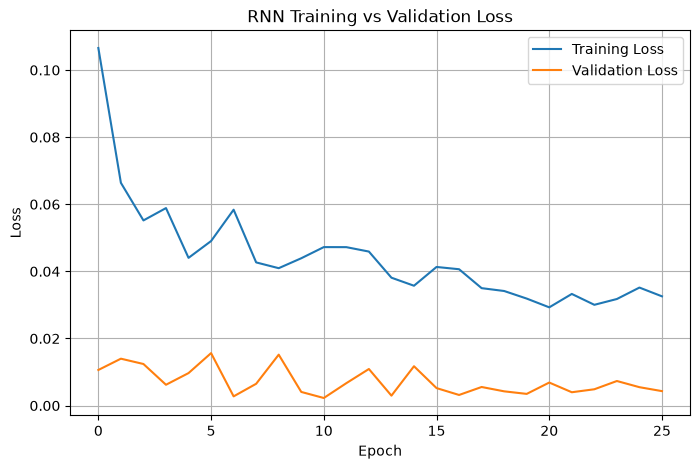

RNN loss graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting\phase3_rnn_loss_graph.png


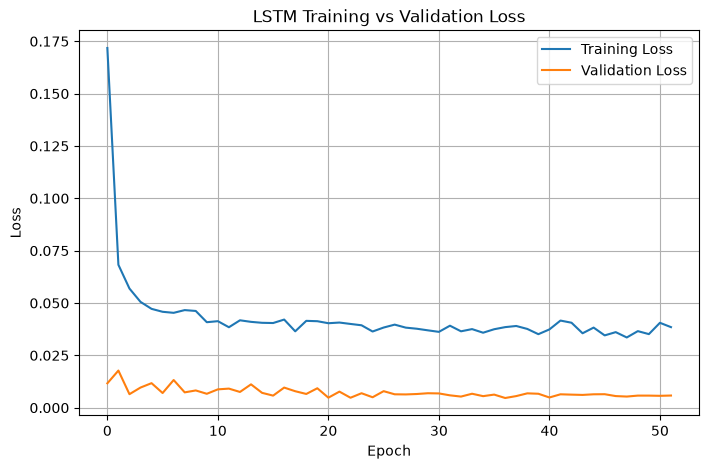

LSTM loss graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting\phase3_lstm_loss_graph.png


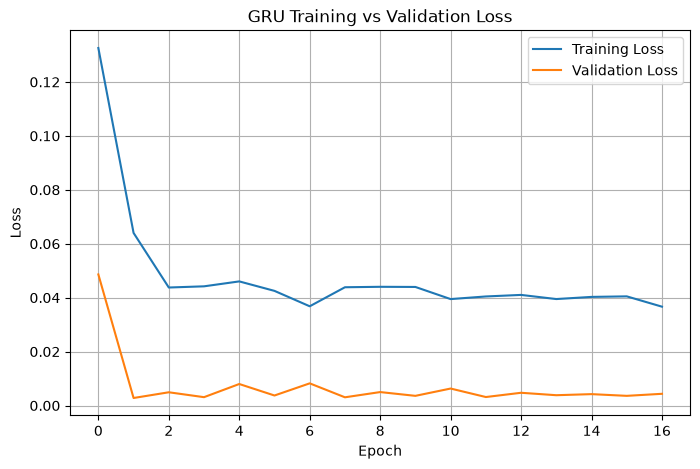

GRU loss graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting\phase3_gru_loss_graph.png


In [23]:
# ============================================================
# Block 20: Plot training and validation loss graphs
# ============================================================

for model_name, history in histories.items():
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    graph_path = os.path.join(
        SCREENSHOTS_DIR,
        f"phase3_{model_name.lower()}_loss_graph.png"
    )

    plt.savefig(graph_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"{model_name} loss graph saved at:", graph_path)

In [24]:
# ============================================================
# Block 21: Check underfitting and overfitting signs
# ============================================================

fit_diagnosis = []

for model_name, history in histories.items():
    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]
    gap = final_val_loss - final_train_loss

    if final_train_loss > 0.05 and final_val_loss > 0.05:
        status = "Possible underfitting: both training and validation loss are high."
    elif gap > final_train_loss * 0.75:
        status = "Possible overfitting: validation loss is much higher than training loss."
    else:
        status = "No strong overfitting/underfitting sign based on final losses."

    fit_diagnosis.append({
        "Model": model_name,
        "Final_Training_Loss": final_train_loss,
        "Final_Validation_Loss": final_val_loss,
        "Validation_Training_Gap": gap,
        "Diagnosis": status
    })

fit_diagnosis_df = pd.DataFrame(fit_diagnosis)
display(fit_diagnosis_df)

fit_report_path = os.path.join(RESULTS_DIR, "phase3_overfitting_underfitting_check.csv")
fit_diagnosis_df.to_csv(fit_report_path, index=False)

print("Fit diagnosis saved at:", fit_report_path)

,Model,Final_Training_Loss,Final_Validation_Loss,Validation_Training_Gap,Diagnosis
0,RNN,0.032562,0.004313,-0.028250,No strong overfitting/underfitting sign based ...
1,LSTM,0.038491,0.005829,-0.032662,No strong overfitting/underfitting sign based ...
2,GRU,0.036662,0.004353,-0.032309,No strong overfitting/underfitting sign based ...


Fit diagnosis saved at: E:\AI Project\AgriMind_Project\results\phase3_crop_price_forecasting\phase3_overfitting_underfitting_check.csv


In [25]:
# ============================================================
# Block 22: Evaluate RNN, LSTM, and GRU models on test data
# ============================================================

evaluation_results = []
predictions_data = {}

for model_name, model in trained_models.items():
    y_pred_scaled = model.predict(X_test, verbose=0).flatten()

    metrics, y_true_original, y_pred_original = evaluate_forecasting_model(
        model_name,
        y_test,
        y_pred_scaled
    )

    evaluation_results.append(metrics)

    predictions_data[model_name] = {
        "y_true": y_true_original,
        "y_pred": y_pred_original
    }

results_df = pd.DataFrame(evaluation_results)
display(results_df)

results_path = os.path.join(RESULTS_DIR, "phase3_rnn_lstm_gru_crop_price_results.csv")
results_df.to_csv(results_path, index=False)

print("Evaluation results saved at:", results_path)

,Model,MAE,MSE,RMSE,MAPE,R2_Score
0,RNN,536.248168,536861.243686,732.708157,13.213715,0.299877
1,LSTM,482.138024,439052.838040,662.610623,12.953982,0.427429
2,GRU,496.858245,430792.417759,656.347787,13.401984,0.438202


Evaluation results saved at: E:\AI Project\AgriMind_Project\results\phase3_crop_price_forecasting\phase3_rnn_lstm_gru_crop_price_results.csv


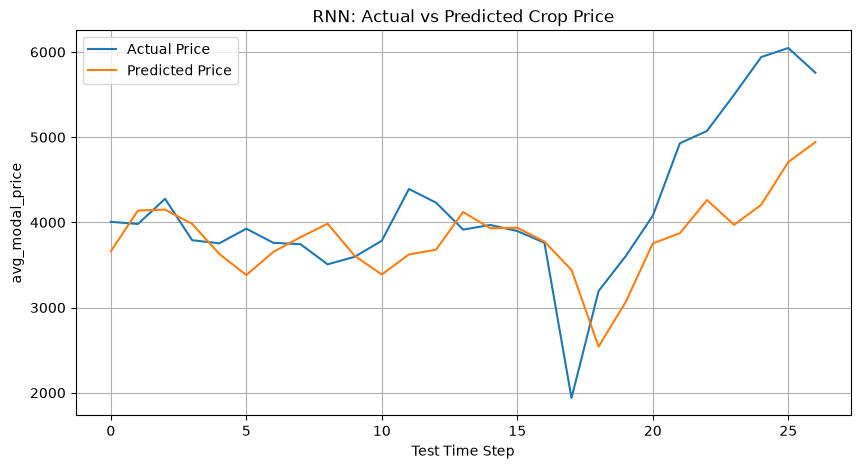

RNN actual vs predicted graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting\phase3_rnn_actual_vs_predicted.png


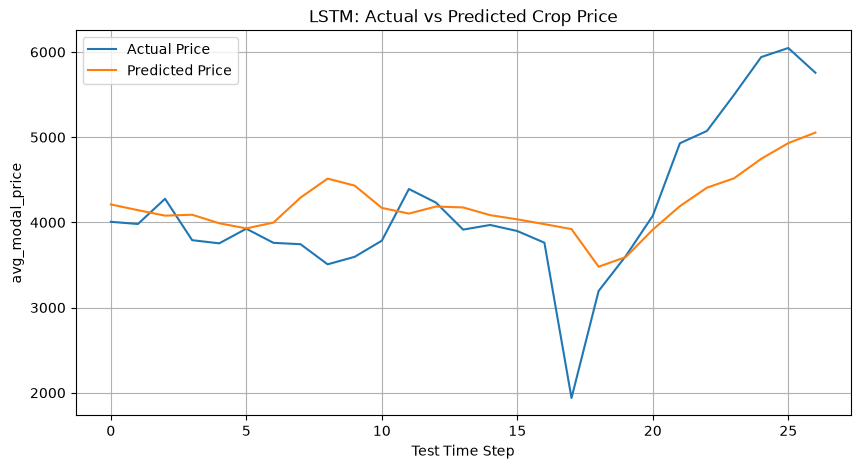

LSTM actual vs predicted graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting\phase3_lstm_actual_vs_predicted.png


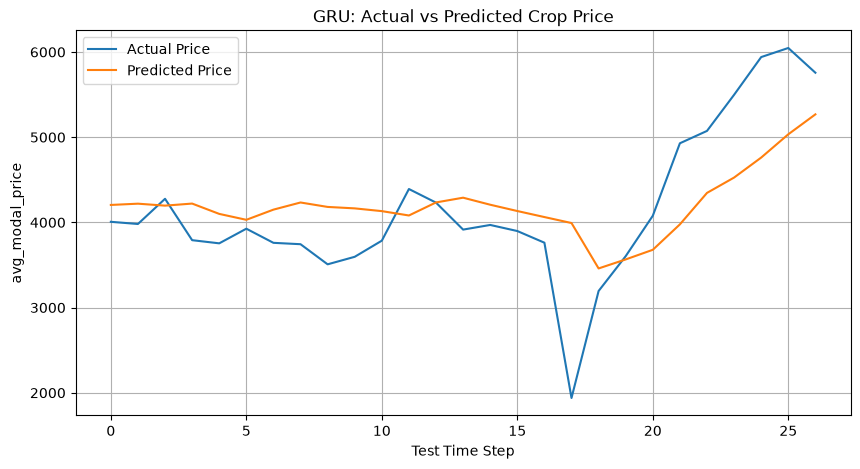

GRU actual vs predicted graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting\phase3_gru_actual_vs_predicted.png


In [26]:
# ============================================================
# Block 23: Actual vs predicted graphs
# ============================================================

for model_name, data in predictions_data.items():
    plt.figure(figsize=(10, 5))
    plt.plot(data["y_true"], label="Actual Price")
    plt.plot(data["y_pred"], label="Predicted Price")
    plt.title(f"{model_name}: Actual vs Predicted Crop Price")
    plt.xlabel("Test Time Step")
    plt.ylabel(TARGET_COLUMN)
    plt.legend()
    plt.grid(True)

    graph_path = os.path.join(
        SCREENSHOTS_DIR,
        f"phase3_{model_name.lower()}_actual_vs_predicted.png"
    )

    plt.savefig(graph_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"{model_name} actual vs predicted graph saved at:", graph_path)

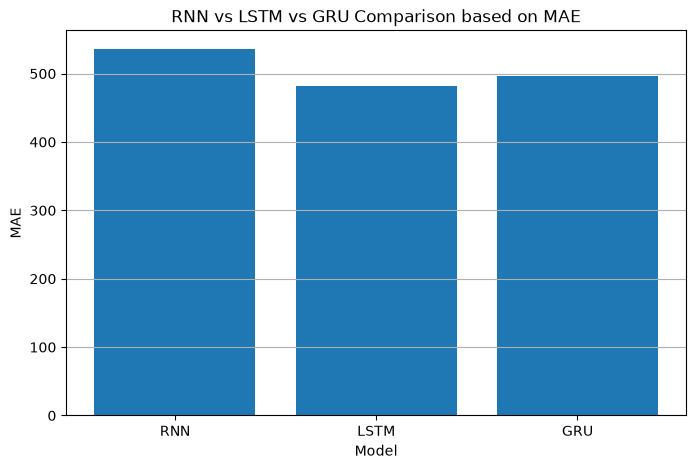

MAE comparison graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting\phase3_model_comparison_mae.png


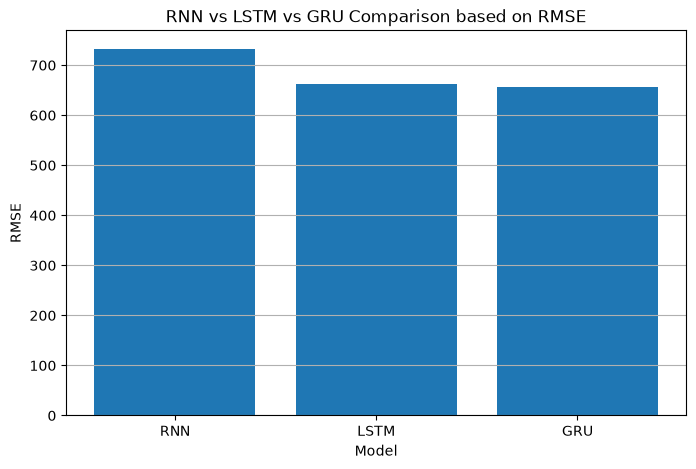

RMSE comparison graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting\phase3_model_comparison_rmse.png


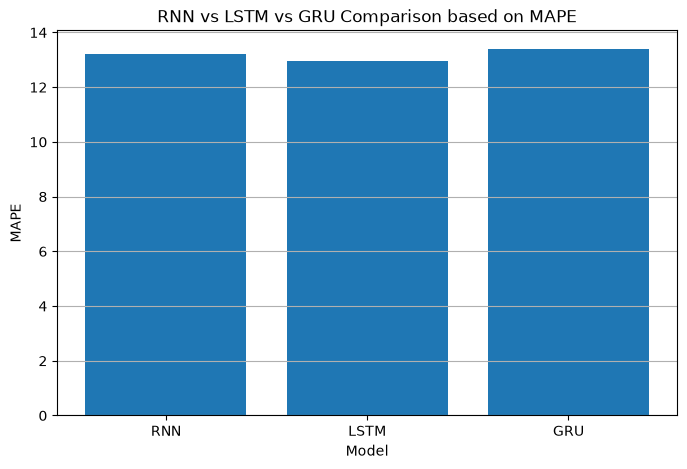

MAPE comparison graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting\phase3_model_comparison_mape.png


In [27]:
# ============================================================
# Block 24: Model comparison graphs
# ============================================================

metrics_to_plot = ["MAE", "RMSE", "MAPE"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(results_df["Model"], results_df[metric])
    plt.title(f"RNN vs LSTM vs GRU Comparison based on {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.grid(axis="y")

    graph_path = os.path.join(
        SCREENSHOTS_DIR,
        f"phase3_model_comparison_{metric.lower()}.png"
    )

    plt.savefig(graph_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"{metric} comparison graph saved at:", graph_path)


RNN Direction Classification Report
              precision    recall  f1-score   support

        Down       0.30      0.33      0.32         9
      Stable       0.00      0.00      0.00         3
          Up       0.50      0.50      0.50        14

    accuracy                           0.38        26
   macro avg       0.27      0.28      0.27        26
weighted avg       0.37      0.38      0.38        26



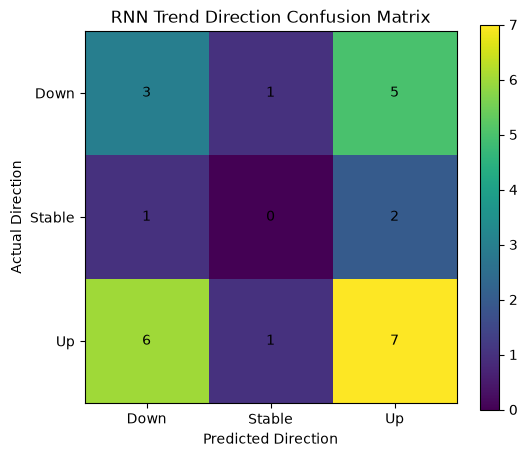

RNN direction confusion matrix saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting\phase3_rnn_trend_direction_confusion_matrix.png

LSTM Direction Classification Report
              precision    recall  f1-score   support

        Down       0.25      0.33      0.29         9
      Stable       0.00      0.00      0.00         3
          Up       0.58      0.50      0.54        14

    accuracy                           0.38        26
   macro avg       0.28      0.28      0.27        26
weighted avg       0.40      0.38      0.39        26



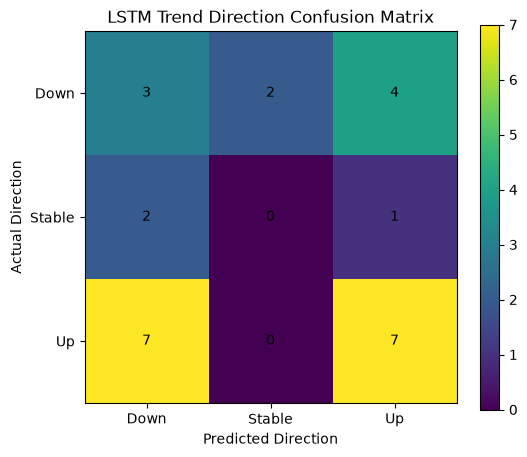

LSTM direction confusion matrix saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting\phase3_lstm_trend_direction_confusion_matrix.png

GRU Direction Classification Report
              precision    recall  f1-score   support

        Down       0.44      0.44      0.44         9
      Stable       0.20      0.33      0.25         3
          Up       0.58      0.50      0.54        14

    accuracy                           0.46        26
   macro avg       0.41      0.43      0.41        26
weighted avg       0.49      0.46      0.47        26



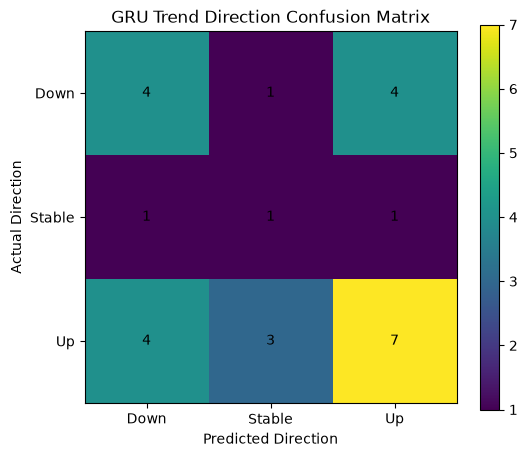

GRU direction confusion matrix saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting\phase3_gru_trend_direction_confusion_matrix.png


In [28]:
# ============================================================
# Block 25: Trend-direction confusion matrix
# ============================================================

# For regression, a standard classification confusion matrix is not the main metric.
# However, to provide a useful visualization, we create a direction-based confusion matrix:
# price went Up / Down / Stable.

def price_direction(values, threshold_percentage=1.0):
    directions = []

    for i in range(1, len(values)):
        previous = values[i - 1]
        current = values[i]

        if previous == 0:
            directions.append("Stable")
            continue

        percentage_change = ((current - previous) / previous) * 100

        if percentage_change > threshold_percentage:
            directions.append("Up")
        elif percentage_change < -threshold_percentage:
            directions.append("Down")
        else:
            directions.append("Stable")

    return np.array(directions)

direction_labels = ["Down", "Stable", "Up"]

for model_name, data in predictions_data.items():
    actual_direction = price_direction(data["y_true"])
    predicted_direction = price_direction(data["y_pred"])

    cm = confusion_matrix(
        actual_direction,
        predicted_direction,
        labels=direction_labels
    )

    print()
    print(f"{model_name} Direction Classification Report")
    print(classification_report(
        actual_direction,
        predicted_direction,
        labels=direction_labels,
        zero_division=0
    ))

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(f"{model_name} Trend Direction Confusion Matrix")
    plt.xlabel("Predicted Direction")
    plt.ylabel("Actual Direction")
    plt.colorbar()

    tick_marks = np.arange(len(direction_labels))
    plt.xticks(tick_marks, direction_labels)
    plt.yticks(tick_marks, direction_labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    graph_path = os.path.join(
        SCREENSHOTS_DIR,
        f"phase3_{model_name.lower()}_trend_direction_confusion_matrix.png"
    )

    plt.savefig(graph_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"{model_name} direction confusion matrix saved at:", graph_path)

In [29]:
# ============================================================
# Block 26: Select best model
# ============================================================

best_row = results_df.sort_values(by="RMSE", ascending=True).iloc[0]
BEST_MODEL_NAME = best_row["Model"]

print("Best model based on lowest RMSE:", BEST_MODEL_NAME)
print(best_row)

Best model based on lowest RMSE: GRU
Model                 GRU
MAE            496.858245
MSE         430792.417759
RMSE           656.347787
MAPE            13.401984
R2_Score         0.438202
Name: 2, dtype: object


In [30]:
# ============================================================
# Block 27: Save trained models, scalers, encoders, and metadata
# ============================================================

for model_name, model in trained_models.items():
    model_path = os.path.join(
        MODEL_DIR,
        f"agrimind_phase3_{model_name.lower()}_crop_price_forecasting.keras"
    )

    model.save(model_path)
    print(f"{model_name} model saved at:", model_path)

feature_scaler_path = os.path.join(MODEL_DIR, "phase3_feature_scaler.pkl")
target_scaler_path = os.path.join(MODEL_DIR, "phase3_target_scaler.pkl")
label_encoders_path = os.path.join(MODEL_DIR, "phase3_label_encoders.pkl")

with open(feature_scaler_path, "wb") as f:
    pickle.dump(feature_scaler, f)

with open(target_scaler_path, "wb") as f:
    pickle.dump(target_scaler, f)

with open(label_encoders_path, "wb") as f:
    pickle.dump(label_encoders, f)

metadata = {
    "phase": "Phase 3",
    "module": "Agricultural Crop Price Forecasting",
    "dataset_path": DATASET_PATH,
    "dataset_source": DATASET_SOURCE,
    "selected_commodity": str(SELECTED_COMMODITY),
    "date_column": DATE_COLUMN,
    "target_column": TARGET_COLUMN,
    "feature_columns": feature_columns,
    "sequence_length": SEQUENCE_LENGTH,
    "train_validation_test_split": "70/15/15 chronological split",
    "models": list(trained_models.keys()),
    "best_model": BEST_MODEL_NAME,
    "evaluation_metrics": ["MAE", "MSE", "RMSE", "MAPE", "R2 Score"]
}

metadata_path = os.path.join(MODEL_DIR, "phase3_metadata.json")

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Feature scaler saved at:", feature_scaler_path)
print("Target scaler saved at:", target_scaler_path)
print("Label encoders saved at:", label_encoders_path)
print("Metadata saved at:", metadata_path)

RNN model saved at: E:\AI Project\AgriMind_Project\models\phase3_crop_price_forecasting\agrimind_phase3_rnn_crop_price_forecasting.keras
LSTM model saved at: E:\AI Project\AgriMind_Project\models\phase3_crop_price_forecasting\agrimind_phase3_lstm_crop_price_forecasting.keras
GRU model saved at: E:\AI Project\AgriMind_Project\models\phase3_crop_price_forecasting\agrimind_phase3_gru_crop_price_forecasting.keras
Feature scaler saved at: E:\AI Project\AgriMind_Project\models\phase3_crop_price_forecasting\phase3_feature_scaler.pkl
Target scaler saved at: E:\AI Project\AgriMind_Project\models\phase3_crop_price_forecasting\phase3_target_scaler.pkl
Label encoders saved at: E:\AI Project\AgriMind_Project\models\phase3_crop_price_forecasting\phase3_label_encoders.pkl
Metadata saved at: E:\AI Project\AgriMind_Project\models\phase3_crop_price_forecasting\phase3_metadata.json


In [31]:
# ============================================================
# Block 28: Save preprocessing and experiment report
# ============================================================

preprocessing_report = {
    "phase": "Phase 3",
    "module": "Agricultural Crop Price Forecasting using RNN, LSTM, and GRU",
    "honesty_note": "The dataset is an Indian crop price dataset, not a direct pesticide/fertilizer price dataset. The model demonstrates agricultural market price forecasting.",
    "source_of_dataset": DATASET_SOURCE,
    "dataset_characteristics": dataset_characteristics,
    "selected_commodity": str(SELECTED_COMMODITY),
    "preprocessing_steps": {
        "importing_libraries": True,
        "importing_dataset": True,
        "date_parsing": f"{DATE_COLUMN} converted to datetime",
        "train_validation_test_split": "70% train, 15% validation, 15% test without shuffling",
        "handling_missing_values": "Numerical median and categorical mode",
        "treating_outliers": "IQR clipping on price columns",
        "duplicate_records": "Removed using drop_duplicates",
        "feature_scaling": "MinMaxScaler for feature and target scaling",
        "handling_categorical_variables": "LabelEncoder used for categorical columns as reference; selected commodity converted into time-series",
        "feature_selection": "avg_modal_price selected as target; min/max price and seasonal month features selected as input features"
    },
    "model_development": {
        "models": ["RNN", "LSTM", "GRU"],
        "overfitting_underfitting_control": [
            "Dropout layers",
            "EarlyStopping with restore_best_weights",
            "ReduceLROnPlateau",
            "Validation loss monitoring",
            "Train/validation/test chronological split"
        ]
    },
    "evaluation_metrics": ["MAE", "MSE", "RMSE", "MAPE", "R2 Score"],
    "best_model": BEST_MODEL_NAME
}

report_path = os.path.join(
    RESULTS_DIR,
    "phase3_preprocessing_and_experiment_report.json"
)

with open(report_path, "w") as f:
    json.dump(preprocessing_report, f, indent=4)

print("Preprocessing and experiment report saved at:", report_path)

Preprocessing and experiment report saved at: E:\AI Project\AgriMind_Project\results\phase3_crop_price_forecasting\phase3_preprocessing_and_experiment_report.json


In [32]:
# ============================================================
# Block 29: Final summary
# ============================================================

print("============================================================")
print("AgriMind Phase 3 Crop Price Forecasting Completed")
print("============================================================")
print("Dataset:", DATASET_PATH)
print("Selected commodity:", SELECTED_COMMODITY)
print("Target column:", TARGET_COLUMN)
print("Feature columns:", feature_columns)
print("Best model:", BEST_MODEL_NAME)
print("Model folder:", MODEL_DIR)
print("Results folder:", RESULTS_DIR)
print("Screenshots folder:", SCREENSHOTS_DIR)
print("============================================================")

display(results_df)
display(fit_diagnosis_df)

AgriMind Phase 3 Crop Price Forecasting Completed
Dataset: E:\AI Project\AgriMind_Project\datasets\Fertilizer_Prize_Dataset\crop_price_dataset.csv
Selected commodity: Coconut
Target column: avg_modal_price
Feature columns: ['avg_modal_price', 'avg_min_price', 'avg_max_price', 'month_sin', 'month_cos']
Best model: GRU
Model folder: E:\AI Project\AgriMind_Project\models\phase3_crop_price_forecasting
Results folder: E:\AI Project\AgriMind_Project\results\phase3_crop_price_forecasting
Screenshots folder: E:\AI Project\AgriMind_Project\screenshots\phase3_crop_price_forecasting


,Model,MAE,MSE,RMSE,MAPE,R2_Score
0,RNN,536.248168,536861.243686,732.708157,13.213715,0.299877
1,LSTM,482.138024,439052.838040,662.610623,12.953982,0.427429
2,GRU,496.858245,430792.417759,656.347787,13.401984,0.438202


,Model,Final_Training_Loss,Final_Validation_Loss,Validation_Training_Gap,Diagnosis
0,RNN,0.032562,0.004313,-0.028250,No strong overfitting/underfitting sign based ...
1,LSTM,0.038491,0.005829,-0.032662,No strong overfitting/underfitting sign based ...
2,GRU,0.036662,0.004353,-0.032309,No strong overfitting/underfitting sign based ...
